In [5]:
!python --version

Python 3.11.2


In [149]:
!python -m pip install torchsummary 


[notice] A new release of pip is available: 23.3.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import numpy
numpy.__version__

'1.26.4'

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchsummary 

import albumentations as A
from albumentations.pytorch import ToTensorV2

c:\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [103]:
cv2.__version__

'4.10.0'

In [104]:
torch.__version__

'2.0.1+cpu'

In [2]:

class CNA(nn.Module):
    def __init__(self, in_nc, out_nc, stride=1):
        super().__init__()
        
        self.conv = nn.Conv2d(in_nc, out_nc, 3, stride=stride, padding=1, bias=False)
        self.norm = nn.BatchNorm2d(out_nc)
        self.act = nn.GELU() #nn.GELU()nn.ReLU()
        
    def forward(self, x):
        out = self.conv(x)
        out = self.norm(out)
        out = self.act(out)
        
        return out
class UnetBlock(nn.Module):
    def __init__(self, in_nc, inner_nc, out_nc, inner_block=None):
        super().__init__()
        
        self.conv1 = CNA(in_nc, inner_nc, stride=2)
        self.conv2 = CNA(inner_nc, inner_nc)
        self.inner_block = inner_block
        self.conv3 = CNA(inner_nc, inner_nc)
        self.conv_cat = nn.Conv2d(inner_nc+in_nc, out_nc, 3, padding=1)
        
    def forward(self, x):
        _,_,h,w = x.shape
        
        inner = self.conv1(x)
        inner = self.conv2(inner)
        #print(inner.shape)
        if self.inner_block is not None:
            inner = self.inner_block(inner)
        inner = self.conv3(inner)
        
        inner = F.upsample(inner, size=(h,w), mode='bilinear')
        inner = torch.cat((x, inner), axis=1)
        out = self.conv_cat(inner)
        
        return out
class Unet(nn.Module):
    def __init__(self, in_nc=1, nc=32, out_nc=1, num_downs=6):
        super().__init__()
        
        self.cna1 = CNA(in_nc, nc)
        self.cna2 = CNA(nc, nc)
        
        unet_block = None
        for i in range(num_downs-3):
            unet_block = UnetBlock(8*nc, 8*nc, 8*nc, unet_block)
        unet_block = UnetBlock(4*nc, 8*nc, 4*nc, unet_block)
        unet_block = UnetBlock(2*nc, 4*nc, 2*nc, unet_block)
        self.unet_block = UnetBlock(nc, 2*nc, nc, unet_block)
        
        self.cna3 = CNA(nc, nc)
        
        self.conv_last = nn.Conv2d(nc, out_nc, 3, padding=1)

    def forward(self, x):
        out = self.cna1(x)
        out = self.cna2(out)
        out = self.unet_block(out)
        out = self.cna3(out)
        out = self.conv_last(out)
        
        return out



In [3]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self,  images_directory, masks_directory, transform=None):
        self.images_directory = images_directory
        self.masks_directory = masks_directory
        self.transform = transform
        print(self.images_directory,self.masks_directory)
        self.images_filenames = sorted(os.listdir(self.images_directory))

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        image_filename = self.images_filenames[idx]
        # print(image_filename)
        image = cv2.imread(os.path.join(self.images_directory, image_filename), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.masks_directory, image_filename), cv2.IMREAD_COLOR)[:,:,0:1]
        image = image.astype(np.float32)/255.0
        mask = mask.astype(np.float32)/255.0
        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
            mask = np.transpose(mask, (2,0,1))
            
            #mask = torch.from_numpy(mask)
        return image, mask

train_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=256, min_width=256),
        A.RandomCrop(256, 256),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        #A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
        #A.RandomBrightnessContrast(p=0.5),
        #A.Normalize(mean=(1.0, 1.0, 1.0), std=(1.0, 1.0, 1.0)),
        ToTensorV2(),
    ]
)

ds_images_path = './Pipes'
ds_masks_path = './Answears'
ds_train = MyDataset(ds_images_path, ds_masks_path, transform=train_transform)
print(len(ds_train))
for i in range(1):
    print(ds_train[i][0].max(),ds_train[i][0].shape)
    print(ds_train[i][1].max(),ds_train[i][1].shape)

./Pipes ./Answears
11
tensor(1.) torch.Size([3, 256, 256])
tensor(1.) torch.Size([1, 256, 256])


./Pipes ./Answears


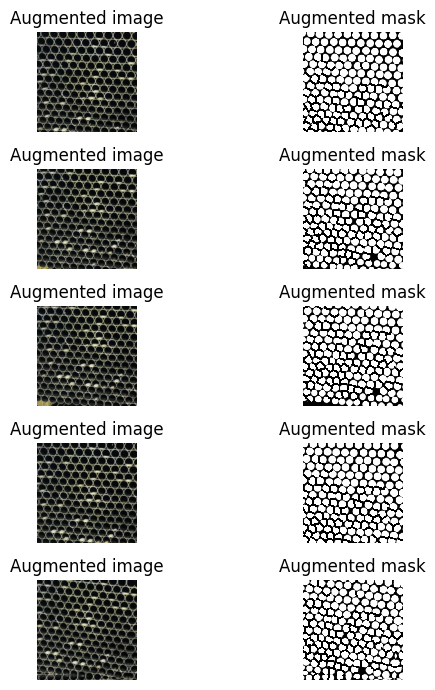

In [4]:
ds_train = MyDataset(ds_images_path, ds_masks_path, transform=train_transform)
#ds_train[0][0].max()
def visualize_augmentations(dataset, idx=0, samples=5):
    dataset = copy.deepcopy(dataset)
    dataset.transform = A.Compose([t for t in dataset.transform if not isinstance(t, (A.Normalize, ToTensorV2))])
    figure, ax = plt.subplots(nrows=samples, ncols=2, figsize=(7, 7))
    for i in range(samples):
        image, mask = dataset[idx]
        mask = np.transpose(mask, (1,2,0))
        # print(image,mask)
        ax[i, 0].imshow(image)
        ax[i, 1].imshow(mask, interpolation="nearest",cmap='gray')
        ax[i, 0].set_title("Augmented image")
        ax[i, 1].set_title("Augmented mask")
        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()
    plt.tight_layout()
    plt.show()
visualize_augmentations(ds_train, 5,5)

In [5]:
batch_size = 11
train_loader = torch.utils.data.DataLoader(
    ds_train, shuffle=True, 
    batch_size=batch_size, num_workers=0, drop_last=True
)

device =  'cpu' #'cuda'
unet_model = Unet(in_nc=3, nc=32, out_nc=1, num_downs=5)
unet_model = unet_model.to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(unet_model.parameters(), lr=0.001, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
print(unet_model)

Unet(
  (cna1): CNA(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
  )
  (cna2): CNA(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
  )
  (unet_block): UnetBlock(
    (conv1): CNA(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
    )
    (conv2): CNA(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
    

In [6]:
sum(p.numel() for p in unet_model.parameters() if p.requires_grad)

8440481

In [101]:
epochs = 100
for epoch in range(epochs):
    loss_val = 0
    acc_val = 0
    for sample in (pbar := tqdm(train_loader)):
        img, mask = sample
        optimizer.zero_grad()
        
        pred = unet_model(img)
        loss = loss_fn(pred, mask)

        loss.backward()
        loss_item = loss.item()
        loss_val += loss_item

        optimizer.step()
    
    if (loss_val/len(train_loader) < .4) and (epoch % 5 ==0) : scheduler.step()
    #pbar.set_description(f'loss: {loss_item:.5f}\tlr: {scheduler.get_last_lr}')
    print(f'{epoch} {loss_val/len(train_loader)}\t lr: {scheduler.get_last_lr()}')
    #print()

100%|██████████| 1/1 [00:24<00:00, 24.33s/it]


0 0.27835771441459656	 lr: [3.090315438263264e-05]


100%|██████████| 1/1 [00:12<00:00, 12.09s/it]


1 0.2996431291103363	 lr: [3.090315438263264e-05]


100%|██████████| 1/1 [00:09<00:00,  9.20s/it]


...

97 0.2852928638458252	 lr: [4.174557917929298e-06]


100%|██████████| 1/1 [00:09<00:00,  9.10s/it]


98 0.27952277660369873	 lr: [4.174557917929298e-06]


100%|██████████| 1/1 [00:08<00:00,  8.47s/it]

99 0.26231127977371216	 lr: [4.174557917929298e-06]


In [132]:
torch.save(unet_model.state_dict(), "unet_model")

In [6]:
unet_model.load_state_dict(torch.load("unet_model"))

<All keys matched successfully>

In [7]:
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

BATCH_SIZE = 12
IMG_SIZE = 28
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.RandomRotation(degrees=(30, 70)),
    transforms.ToTensor(),
    # transforms.Normalize(
    #     mean=[0.5, 0.5, 0.5],
    #     std=[0.5, 0.5, 0.5]
    # )
])
spot_dataset = torchvision.datasets.ImageFolder(root='Spots',transform=train_transform)
spot_loader = DataLoader(spot_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(spot_dataset.classes)
print(spot_dataset[0][0].shape)

class ConvNet(nn.Module): 
    def __init__(self): 
         super(ConvNet, self).__init__() 
         self.layer1 = nn.Sequential( nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2)) 
         self.layer2 = nn.Sequential( nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2), nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2)) 
         self.drop_out = nn.Dropout() 
         self.fc1 = nn.Linear(7 * 7 * 64, 500) 
         self.fc2 = nn.Linear(500, 4)
    def forward(self, x): 
        out = self.layer1(x) 
        out = self.layer2(out) 
        out = out.reshape(out.size(0), -1) 
        out = self.drop_out(out) 
        out = self.fc1(out) 
        out = self.fc2(out) 
        return out
    
spot_model = ConvNet()
# print(spot_model)

optimizer = torch.optim.Adam(spot_model.parameters(), lr=1e-3)
# loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary

summary(spot_model, (3, 28, 28))


c:\Python\Python311\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Python\Python311\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


['0 - No pipe', '1 - Round Pipe', '2 - Square Pants', '3 - Two pipes']
torch.Size([3, 28, 28])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]           2,432
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          51,264
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
           Dropout-7                 [-1, 3136]               0
            Linear-8                  [-1, 500]       1,568,500
            Linear-9                    [-1, 4]           2,004
Total params: 1,624,200
Trainable params: 1,624,200
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.67

In [191]:
spot_dataset[0][0].max()

tensor(0.9843)

In [8]:
spot_model.load_state_dict(torch.load("spot_model"))

<All keys matched successfully>

torch.Size([256, 256, 1])


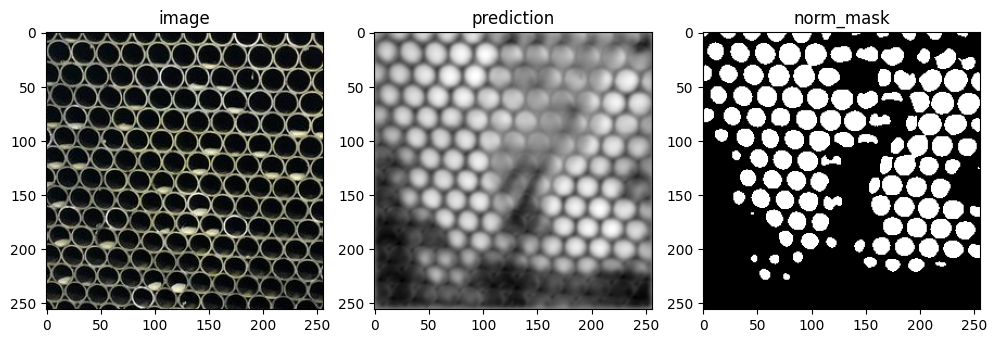

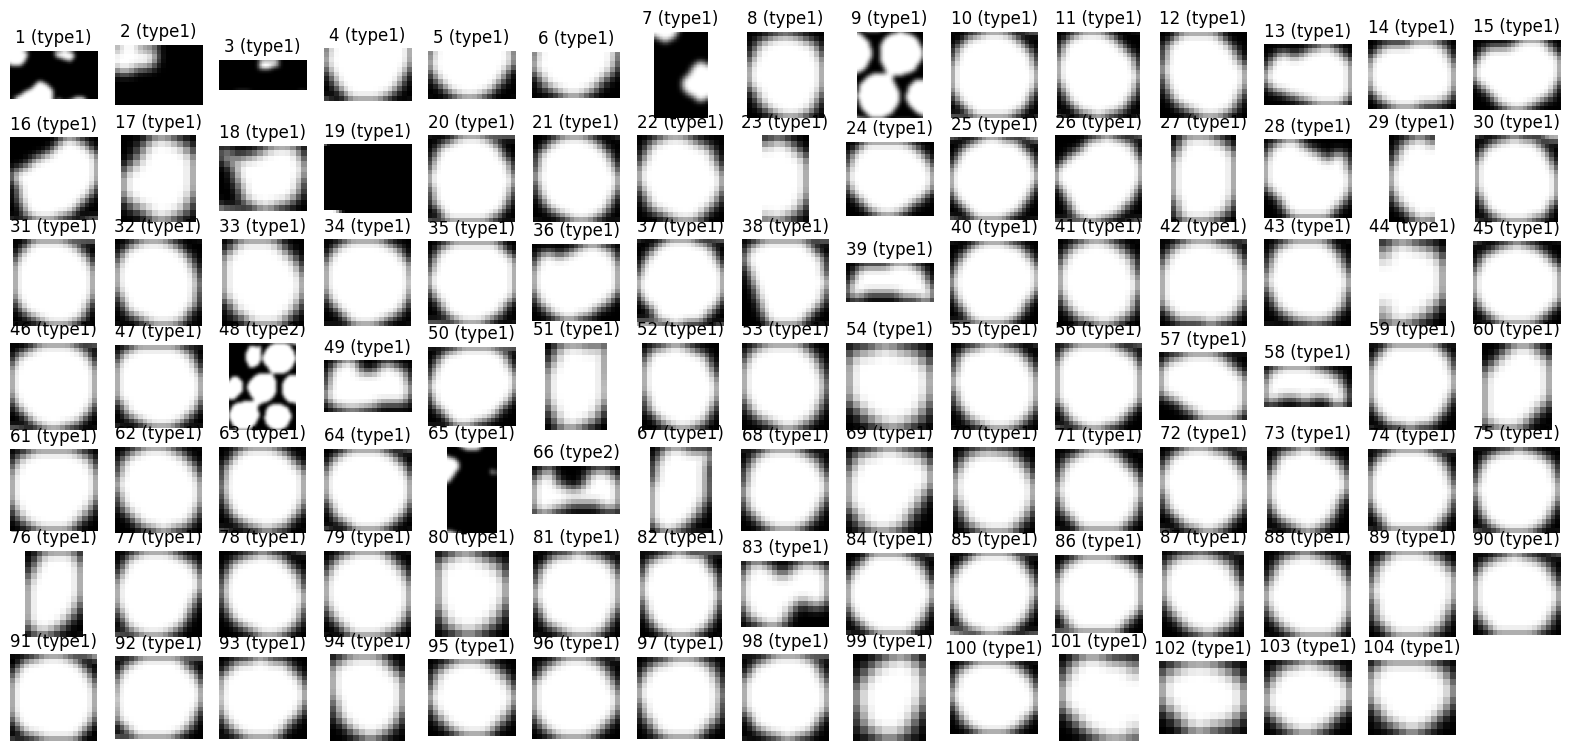

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


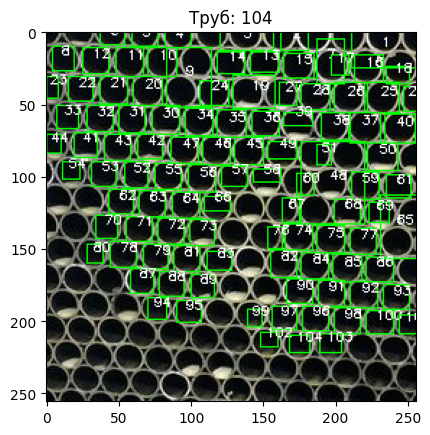

(104, '1.png')

In [25]:
def find_pipe_count(img, showplot = True, pixel_sensitivity = 1/8,semantic_name=''):
    pred = unet_model(img)
    # pred = F.sigmoid(pred.detach()).numpy()[0].transpose(1,2,0) # 
    pred = pred.detach().numpy()[0].transpose(1,2,0) # 
    img_np = img.detach().cpu().numpy()[0].transpose(1,2,0)
    # print(img_np.shape,pred.shape)

    def norm_mask(pred):
        m= pred.max()
        # print(pred.shape,m)
        p = torch.zeros(pred.shape)
        # print(p.shape)
        for i in range(pred.shape[0]):
            for j in range(pred.shape[1]):
                if pred[i,j,0]>(m*pixel_sensitivity) and pred[i,j,0]>0.15:
                    p[i,j,0] = 1.
        return p

    norm = norm_mask(pred)
    if semantic_name != '':
        print(norm.shape)
        mask_img = (norm.numpy() * 255.).astype(np.uint8)
        cv2.imwrite(semantic_name,mask_img[:, :, 0])
    # norm2 = copy.deepcopy(norm)
    if showplot:
        figure, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 24))
        ax[0].imshow(img_np)
        ax[1].imshow(pred,cmap='gray')
        ax[2].imshow(norm,cmap='gray')
        ax[0].set_title("image")
        ax[1].set_title("prediction")
        ax[2].set_title("norm_mask")
        plt.tight_layout()
        plt.show()

    grey=np.uint8(norm.squeeze().numpy()* 255)
    grey = cv2.GaussianBlur(grey,(5,5),0)
    # ret,thresh = cv2.threshold(grey,100,255,cv2.THRESH_BINARY)
    thresh = cv2.adaptiveThreshold(grey,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
    # plt.imshow(thresh, cmap="gray")
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    filtered_contours=[]
    for c in contours:
        x,y,w,h = cv2.boundingRect(c)
        if w*h >=120 and w*h<10000:
            filtered_contours.append(c);
    def myKey(con):
        x,y,w,h=cv2.boundingRect(con)
        return y
    filtered_contours.sort(key=myKey)

    if showplot: 
        figure = plt.figure(figsize=(20,20))
    pipe_count=0
    i=0
    for c in filtered_contours:
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(img_np, (x,y), (x+w, y+h), color=(0, 255, 0), thickness=1)
        # cv2.rectangle(norm2, (x,y), (x+w, y+h),  thickness=1)
        con = grey[y:y+h, x:x+w]
        
        con2=cv2.resize(con,(IMG_SIZE,IMG_SIZE))/255.0
        # con2=np.repeat(con2, 3, axis=2)
        con2 = con2[None, :, :] * np.ones(3, dtype=int)[:, None, None]
        con2=torch.tensor(con2,dtype=torch.float).unsqueeze(0)
        # print(con2.shape)
        # con2= torch.cat((con2,con2,con2),1) #.unsqueeze(0)
        spot_pred = spot_model(con2)
        spot_pred=torch.argmax(spot_pred).item()
        

        if spot_pred>2: 
            pipe_count += 1
            text = str(pipe_count)
            cv2.putText(img_np,text=text, org=(round(x+w/2)-2,round(y+h/2)+10), fontFace=cv2.FONT_HERSHEY_SIMPLEX, thickness=1, color=(255,255,255),fontScale=0.3)
            pipe_count += 1
        elif spot_pred>0: 
            pipe_count += 1
            text=str(pipe_count)
        else:            
            text="NO"

        
        cv2.putText(img_np,text=text, org=(round(x+w/2)-2,round(y+h/2)-2), fontFace=cv2.FONT_HERSHEY_SIMPLEX, thickness=1, color=(255,255,255),fontScale=0.3)
        # cv2.putText(norm2,text=text, org=(round(x+w/2)-2,round(y+h/2)-2), fontFace=cv2.FONT_HERSHEY_SIMPLEX, thickness=1, color=(255,255,255),fontScale=0.3)

        i += 1
        if showplot:
            figure.add_subplot(15, 15, i)
            plt.title(f'{text} (type{spot_pred})')
            plt.axis("off")
            plt.imshow(con, cmap="gray")    
    if showplot:
        plt.show()
        plt.imshow(img_np, cmap="gray")
        plt.title(f'Труб: {pipe_count}')
        plt.show()
        
        # plt.imshow(norm2)
        # plt.show()
    return pipe_count,semantic_name

find_pipe_count(ds_train[5][0].unsqueeze(0),semantic_name='1.png')

In [98]:
def train(model, trainloader, optimizer, criterion):
    model.train()
    print('Training')
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    for i, data in tqdm(enumerate(trainloader), total=len(trainloader)):
        counter += 1
        image, labels = data
        optimizer.zero_grad()
        # forward pass
        outputs = model(image)
        # calculate the loss
        loss = criterion(outputs, labels)
        train_running_loss += loss.item()
        # calculate the accuracy
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == labels).sum().item()
        # backpropagation
        loss.backward()
        # update the optimizer parameters
        optimizer.step()
    
    # loss and accuracy for the complete epoch
    epoch_loss = train_running_loss / counter
    epoch_acc = 100. * (train_running_correct / len(trainloader.dataset))
    return epoch_loss, epoch_acc
# validation
def validate(model, testloader, criterion):
    model.eval()
    print('Validation')
    valid_running_loss = 0.0
    valid_running_correct = 0
    counter = 0
    with torch.no_grad():
        for i, data in tqdm(enumerate(testloader), total=len(testloader)):
            counter += 1
            
            image, labels = data
            # forward pass
            outputs = model(image)
            # calculate the loss
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()
            # calculate the accuracy
            _, preds = torch.max(outputs.data, 1)
            valid_running_correct += (preds == labels).sum().item()
        
    # loss and accuracy for the complete epoch
    epoch_loss = valid_running_loss / counter
    epoch_acc = 100. * (valid_running_correct / len(testloader.dataset))
    return epoch_loss, epoch_acc

train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
epochs=100
for epoch in range(epochs):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(spot_model, spot_loader, 
                                              optimizer, criterion)
    train_loss.append(train_epoch_loss)

    train_acc.append(train_epoch_acc)

    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")

    print('-'*50)

torch.save(spot_model.state_dict(), "spot_model")
print('TRAINING COMPLETE')

[INFO]: Epoch 1 of 100
Training


100%|██████████| 1/1 [00:00<00:00,  1.45it/s]


Training loss: 1.381, training acc: 25.000
--------------------------------------------------
[INFO]: Epoch 2 of 100
Training


100%|██████████| 1/1 [00:00<00:00, 15.67it/s]


Training loss: 1.287, training acc: 50.000
--------------------------------------------------
[INFO]: Epoch 3 of 100
Training


...

Training loss: 0.065, training acc: 100.000
--------------------------------------------------
[INFO]: Epoch 99 of 100
Training


100%|██████████| 1/1 [00:00<00:00, 11.80it/s]


Training loss: 0.038, training acc: 100.000
--------------------------------------------------
[INFO]: Epoch 100 of 100
Training


100%|██████████| 1/1 [00:00<00:00,  5.70it/s]

Training loss: 0.031, training acc: 100.000
--------------------------------------------------
TRAINING COMPLETE


In [99]:
spot_model.load_state_dict(torch.load("spot_model"))

<All keys matched successfully>

In [12]:
val_transform = A.Compose(
    [
        A.PadIfNeeded(min_height=256, min_width=256),
        A.CenterCrop(256, 256),
        #A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)


ds_images_path = './Pipes'
ds_masks_path = './Answears'
val_train = MyDataset(ds_images_path, ds_masks_path, transform=val_transform)
true_counts = {'1.png':20,'2.png':9,'11.png':70,'IMG_2925.png':52,'IMG_2938.png':182,'IMG_2939.png':273,'IMG_2940.png':104,
               'IMG_2942.png':169,'Untitled-1.png':70,'Untitled-2.png':127,'Untitled-3.png':150}
MAPE = []
pipe_counts = []
img_names = []
semantic_names = []

pixel_sensitivity=1/5.5       # 1/8 mean MAPE = 63.4       1/4 mean MAPE = 60.7     1/2 mean MAPE = 70.0      1/5 mean MAPE = 59.6  1/6 59.8
for i in range(len(val_train)):
    img = val_train[i][0].unsqueeze(0)
    filename= val_train.images_filenames[i]
    pred_pipe_count,semantic_name = find_pipe_count(img,showplot=False,pixel_sensitivity=pixel_sensitivity)
    true_count = true_counts[filename]
    # print(val_train.images_filenames[i],val_train[i][0].max(),val_train[i][0].shape)
    mape=abs((true_count - pred_pipe_count)/true_count)
    
    MAPE.append(mape)
    pipe_counts.append(pred_pipe_count)
    img_names.append(filename)
    semantic_names.append(semantic_name)
    
    print(f'{filename}, pred_pipe_count={pred_pipe_count}, true_count={true_count},mape={mape}')
meanMAPE = sum(MAPE)/len(val_train) * 100
print('--------------------')
print(f'mean MAPE = {meanMAPE}')
    


./Pipes ./Answears
1.png, pred_pipe_count=22, true_count=20,mape=0.1
11.png, pred_pipe_count=39, true_count=70,mape=0.44285714285714284
2.png, pred_pipe_count=16, true_count=9,mape=0.7777777777777778
IMG_2925.png, pred_pipe_count=67, true_count=52,mape=0.28846153846153844
IMG_2938.png, pred_pipe_count=89, true_count=182,mape=0.510989010989011
IMG_2939.png, pred_pipe_count=99, true_count=273,mape=0.6373626373626373
IMG_2940.png, pred_pipe_count=33, true_count=104,mape=0.6826923076923077
IMG_2942.png, pred_pipe_count=60, true_count=169,mape=0.6449704142011834
Untitled-1.png, pred_pipe_count=26, true_count=70,mape=0.6285714285714286
Untitled-2.png, pred_pipe_count=28, true_count=127,mape=0.7795275590551181
Untitled-3.png, pred_pipe_count=37, true_count=150,mape=0.7533333333333333
--------------------
mean MAPE = 56.78675591183162


In [15]:
def create_csv_file(csv_name, img_names, semantic_names,pipe_counts):
    with open(csv_name, 'w') as file:
        file.write('img_path;annot_path;pipe_class;pipe_count\n')
        #test/images/0/00001.jpg;test/annotation/semantic/00001.png;0;61;\n')
        for img_name, semantic_name,pipe_count in zip(img_names, semantic_names,pipe_counts):
            file.write(f'{img_name};{semantic_name};0;{pipe_count}\n')

create_csv_file('train_submission.csv', img_names, semantic_names, pipe_counts)

In [33]:
test_path = './test' #test/images/0/00001.jpg

val_train = MyDataset(test_path, test_path, transform=val_transform)
print(len(val_train))
pipe_counts = []
img_names = []
semantic_names = []

pixel_sensitivity=1/3.5       #
for i in range(len(val_train)):
    img = val_train[i][0].unsqueeze(0)
    filename= val_train.images_filenames[i]
    pred_pipe_count,semantic_name = find_pipe_count(img,showplot=False,pixel_sensitivity=pixel_sensitivity,semantic_name='./Annotation/semantic/'+filename)
    pipe_counts.append(pred_pipe_count)
    img_names.append(filename)
    semantic_names.append(semantic_name)
    
    print(f'{filename}, pred_pipe_count={pred_pipe_count}')

create_csv_file('submission.csv', img_names, semantic_names, pipe_counts)

./test ./test
3


c:\Python\Python311\Lib\site-packages\torch\nn\functional.py:3737: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


torch.Size([256, 256, 1])
IMG_2947.JPG, pred_pipe_count=25
torch.Size([256, 256, 1])
IMG_2955.JPG, pred_pipe_count=31
torch.Size([256, 256, 1])
IMG_2956.JPG, pred_pipe_count=24
